In [ ]:
!pip install enoslib ipywidgets --break-system-packages

In [ ]:
!ssh rennes.grid5000.fr hostname

In [ ]:
!ssh-add ~/.ssh/id_ed25519

### G5K connection

Setup the `.python-grid5000.yaml` file with the username and password used to login to grid5000.

The file should look like this:
```yaml
username: G5K_LOGIN
password: G5K_password
```

-> required in order for the enoslib calls to g5k to work.

In addition to this, make sure to add these lines to your ssh configuration:

```text
Host g5k
    User G5K_LOGIN
    HostName access.grid5000.fr
    ForwardAgent no

Host !access.grid5000.fr *.grid5000.fr
    User G5K_LOGIN
    ProxyJump G5K_LOGIN@access.grid5000.fr
    StrictHostKeyChecking no
    UserKnownHostsFile /dev/null
    ForwardAgent yes

Host access.grid5000.fr
    User G5K_LOGIN
    StrictHostKeyChecking no
    UserKnownHostsFile /dev/null
    ForwardAgent yes

Host *.g5k
    User G5K_LOGIN
    ProxyCommand ssh g5k -W "$(basename %h .g5k):%p"
    ForwardAgent no
```

Make sure to replace `G5K_LOGIN` with your g5k username (the one from the site)

### Job configuration

Setup the various parameters for the job:
- The job name will identify the current booking, if the notebook kernel dies, re running the same reservation code with the same name will reload the existing job instead of booking a new one
- The walltime is the time that the booking will last, you can always stop your reservation earlier than the booking's end time

In [1]:
import os
from grid5000 import Grid5000
import enoslib as en
import logging
from datetime import datetime, timedelta

conf_file = os.path.join(os.environ.get("HOME"), ".python-grid5000.yaml") # type: ignore
gk = Grid5000.from_yaml(conf_file)

# map each cluster to its site
cluster_to_site = {}
for site in gk.sites.list():
    for cluster in site.clusters.list():
        cluster_to_site[cluster.uid] = site.uid

# JOB CONFIGURATION
JOB_NAME="fcquic_relay_eval_multisite"
JOB_WALLTIME=timedelta(hours=2, minutes=0)

# usage policy check: the job cannot cross the day to night boundary at 7pm if it was submitted before 5 pm. Any job started after 5 pm can cross the boundary
# I had the issue once so this check is there to avoid receiving a usage policy violation email...
datetime_now = datetime.now()
job_end_dt = datetime_now + JOB_WALLTIME
if datetime_now.hour <= 17 and job_end_dt.hour >= 19:
    raise RuntimeError("This job reservation will violate the usage policy and will cross the day night boundary")


NUM_SERVER_NODES=1
SERVER_CLUSTER="paradoxe"

# number of network namespaces per client server (each ns runs one client binary)
# per discussion with the prof. 5 to 10 namespaces per server is fine
NUM_NS_PER_CLIENT=5

CLIENT_CLUSTERS=[
    # cluster 0
    {"cluster": "ecotype", "num_clients": 1}, # nantes 
]
TOPOLOGY_LINKS = [
    ("router_server", "router_client_0"), # rennes -> nantes 
]


# NOTE: TEST TOPO TO USE
# CLIENT_CLUSTERS=[
#     # cluster 0
#     {"cluster": "gros", "num_clients": 10}, # nancy
#     # cluster 1
#     {"cluster": "paradoxe", "num_clients": 5}, # rennes
#     # cluster 2
#     {"cluster": "ecotype", "num_clients": 10}, # nantes
#     # cluster 3
#     {"cluster": "nova", "num_clients": 4}, # lyon
# ]

# # each entry in the table here is a link between two routers.
# # role names are the keys: "router_server", "router_client_0",...
# TOPOLOGY_LINKS = [
#     ("router_server", "router_client_0"), # LLN -> nancy
#     ("router_server", "router_client_1"), # LLN -> rennes

#     ("router_client_1", "router_client_2"), # rennes -> nantes

#     ("router_client_0", "router_client_3"), # nancy -> lyon
# ]


# Display some general information about the library
en.check()
# Enable rich logging
_ = en.init_logging()
# en.set_config(g5k_auto_jump=False)

conf = (
    en.G5kConf.from_settings(
        job_name=JOB_NAME,
        walltime=str(JOB_WALLTIME),
        env_name="debian12-nfs",
        job_type=["deploy"],
    ) 

    # server router 
    .add_machine(
        roles=["router", "router_server"],
        cluster=SERVER_CLUSTER,
        nodes=1,
    )
    # server
    .add_machine(
        roles=["server"],
        cluster=SERVER_CLUSTER,
        nodes=NUM_SERVER_NODES,
    ) 
    .add_network(
        id="subnet_server",
        type="slash_22",
        roles=["subnet", "subnet_server"],
        site=cluster_to_site[SERVER_CLUSTER],
    )
)

# we need to add one client router + clients + relay + subnet for each client cluster
for i, client_cluster in enumerate(CLIENT_CLUSTERS):
    conf = (
        conf
        # add only one client router
        .add_machine(
            roles=["router", "router_client", f"router_client_{i}"],
            cluster=client_cluster["cluster"],
            nodes=1,
        )
        # add all of the client machines
        .add_machine(
            roles=["client", f"client_{i}"],
            cluster=client_cluster["cluster"],
            nodes=client_cluster["num_clients"],
        )
        # one relay per client cluster
        .add_machine(
            roles=["relay", f"relay_{i}"],
            cluster=client_cluster["cluster"],
            nodes=1,
        )
        .add_network(
            id=f"subnet_client_{i}",
            type="slash_22",
            roles=["subnet", "subnet_client", f"subnet_client_{i}"],
            site=cluster_to_site[client_cluster["cluster"]],
        )
    )

# This will validate the configuration, but not reserve resources yet
provider = en.G5k(conf)


[WARNING]: failed to patch stdout/stderr for fork-safety: 'OutStream' object
has no attribute 'buffer'
[WARNING]: failed to reconfigure stdout/stderr with custom encoding error
handler: 'OutStream' object has no attribute 'reconfigure'


_____        ___  ____  _ _ _
 | ____|_ __  / _ \/ ___|| (_) |__
 |  _| | '_ \| | | \___ \| | | '_ \
 | |___| | | | |_| |___) | | | |_) |
 |_____|_| |_|\___/|____/|_|_|_.__/  10.6.0

 • Documentation: ]8;id=33549;https://discovery.gitlabpages.inria.fr/enoslib/\https://discovery.gitlabpages.inria.fr/enoslib/]8;;\                            
 • Source: ]8;id=86912;https://gitlab.inria.fr/discovery/enoslib\https://gitlab.inria.fr/discovery/enoslib]8;;\                                         
 • Chat: ]8;id=408699;https://framateam.org/enoslib\https://framateam.org/enoslib]8;;\

                         Dependency check                         
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Provider      ┃    Status     ┃ Hint                           ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Chameleon     │ NOT INSTALLED │ pip install enoslib[chameleon] │
│ ChameleonKVM  │ NOT INSTALLED │ pip install enoslib[chameleon] │
│ ChameleonEdge │ NOT INSTALLED │ pip install enoslib[chameleon] │
│ Fabric        │ NOT INSTALLED │ pip install enoslib[fabric]    │
│ Distem        │ NOT INSTALLED │ pip install enoslib[distem]    │
│ IOT-lab       │ NOT INSTALLED │ pip install enoslib[iotlab]    │
│ Grid'5000     │   INSTALLED   │                                │
│ Openstack     │ NOT INSTALLED │ pip install enoslib[chameleon] │
│ Vagrant       │ NOT INSTALLED │ pip install enoslib[vagrant]   │
│ VMonG5k       │   INSTALLED   │                                │
└───────────────┴───────────────┴────────────────────────────────┘

                                Connectivity check                                 
┏━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Provider  ┃ Key                 ┃ Connectivity ┃ Hint                           ┃
┡━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Grid'5000 │ ssh:access          │      ✅      │ Connection to access.grid5000… │
│ Grid'5000 │ ssh:access:frontend │      ✅      │ Connection Host(rennes.grid50… │
│ Grid'5000 │ api:access          │      ✅      │                                │
│ VMonG5k   │ access              │      ❔      │ Check G5k status               │
└───────────┴─────────────────────┴──────────────┴────────────────────────────────┘

In [2]:
print("Reserving resources...")

# Get actual resources
roles, networks = provider.init()
display(roles)
display(networks)

# Fill in network information from nodes
roles = en.sync_info(roles, networks)

with en.actions(roles=roles) as a:
    a.apt(task_name="Install traceroute", name="traceroute", state="present")
    a.apt(task_name="Install btop", name="btop", state="present")
    a.apt(task_name="Install htop", name="htop", state="present")
    a.apt(task_name="Install tcpdump", name="tcpdump", state="present")
with en.actions(roles=roles["router"], gather_facts=True) as a:
    a.file(
        task_name="Ensure apt keyring directory exists",
        path="/usr/share/keyrings",
        state="directory",
        mode="0755",
    )
    a.get_url(
        task_name="Download FRR GPG key",
        url="https://deb.frrouting.org/frr/keys.gpg",
        dest="/usr/share/keyrings/frrouting.gpg",
        mode="0644",
    )
    a.apt_repository(
        task_name="Add FRR apt repository",
        repo="deb [signed-by=/usr/share/keyrings/frrouting.gpg] https://deb.frrouting.org/frr {{ ansible_distribution_release }} frr-stable",
        filename="frr",
        state="present",
    )
    a.apt(
        task_name="Install FRR packages",
        name=["frr", "frr-pythontools"],
        state="present",
        update_cache=True,
    )
    results = a.results


# with en.actions(roles=roles["server"]) as a:
#     a.apt(task_name="Install tshark", name="tshark", state="present")


Reserving resources...


INFO     [ProviderS] Common reservation_date=2026-04-22T15:06:30 (local time) ]8;id=944272;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/providers.py\providers.py]8;;\:]8;id=388229;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/providers.py#60\60]8;;\
         [2 providers]                                                                       

INFO     [G5k] Submitting {'name': 'fcquic_relay_eval_multisite',        ]8;id=935862;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=843108;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#304\304]8;;\
         'types': ['deploy', 'origin=enoslib_g5k'], 'resources': "{clust                     
         er='paradoxe'}/nodes=1+{cluster='paradoxe'}/nodes=1+slash_22=1,                     
         walltime=2:00:00", 'command': 'sleep 31536000', 'queue':                            
         'default', 'reservation': '2026-04-22 15:06:31'} on rennes                          

INFO     [G5k] Submitting {'name': 'fcquic_relay_eval_multisite',        ]8;id=178425;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=943235;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#304\304]8;;\
         'types': ['deploy', 'origin=enoslib_g5k'], 'resources': "{clust                     
         er='ecotype'}/nodes=1+{cluster='ecotype'}/nodes=1+{cluster='eco                     
         type'}/nodes=1+slash_22=1,walltime=2:00:00", 'command': 'sleep                      
         31536000', 'queue': 'default', 'reservation': '2026-04-22                           
         15:06:40'} on nantes                                                                

INFO     [G5k] Reloading 314990 from nantes                              ]8;id=256721;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=871965;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#167\167]8;;\

...

Finished 4 tasks (Install traceroute,Install btop,Install htop,Install tcpdump) on 
{'ecotype-34.nantes.grid5000.fr', 'paradoxe-51.rennes.grid5000.fr', 
'ecotype-4.nantes.grid5000.fr', 'ecotype-31.nantes.grid5000.fr', 
'paradoxe-43.rennes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Output()

Finished 5 tasks (Gather facts,Ensure apt keyring directory exists,Download FRR GPG key,Add 
FRR apt repository,Install FRR packages) on {'ecotype-31.nantes.grid5000.fr', 
'paradoxe-43.rennes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

### Interface setup
- We first need to get the name of the primary interface for each node, this is the interface that is connected to the "prod" network
- Then we need to assign IPs from our subnet to the nodes


In [3]:
prod_interfaces_per_node = {}
# node_ips = {}

# find the physical interface connected to the production network
for host in roles["client"] + roles["server"] + roles["router"] + roles["relay"]:
    node_name = host.address

    prod_interfaces = host.filter_interfaces(networks=networks["prod"])    
    if prod_interfaces:
        prod_interface_name = prod_interfaces[0]
        print(f"Prod interface for {host.alias}: {prod_interface_name}")
        prod_interfaces_per_node[host.alias] = prod_interface_name


    else:
        print(f"Couldn't find prod iface for {host.alias}")
    
     
    # get each node's IP address on the production network
    # ip_address_obj = host.filter_addresses(networks=networks["prod"])[0]
    # # This may seem weird: ip_address_obj.ip is a `netaddr.IPv4Interface`
    # # which itself has an `ip` attribute.
    # node_ip = ip_address_obj.ip.ip
    # if node_ips.get(node_name) is None:
    #     node_ips[node_name] = []
    # node_ips[node_name].append(node_ip.exploded)
    # host.extra.update(ips=node_ips[node_name])


display(prod_interfaces_per_node)
# display(node_ips)

Prod interface for ecotype-34.nantes.grid5000.fr: eno1
Prod interface for ecotype-4.nantes.grid5000.fr: eno1
Prod interface for ecotype-31.nantes.grid5000.fr: eno1
Prod interface for paradoxe-43.rennes.grid5000.fr: ens10f0np0
Prod interface for paradoxe-51.rennes.grid5000.fr: ens10f0np0


{'ecotype-34.nantes.grid5000.fr': 'eno1',
 'ecotype-4.nantes.grid5000.fr': 'eno1',
 'ecotype-31.nantes.grid5000.fr': 'eno1',
 'paradoxe-43.rennes.grid5000.fr': 'ens10f0np0',
 'paradoxe-51.rennes.grid5000.fr': 'ens10f0np0'}

### Assigning IPs from subnets

In [4]:
from itertools import islice, product
import subprocess


node_ips = {}
# all namespace IPs across all client nodes (flat list for passing to NPF)
all_ns_ips = []

server_ips = networks["subnet_server"][0].free_ips

def assign_n_ips_to_hosts(role, N, ips):
    global node_ips

    for host in roles[role]:

        host_prod_iface = prod_interfaces_per_node[host.alias]
        host.extra.update(ips=[str(ip) for ip in islice(ips, N)])
        
        for ip in host.extra.get("ips"):

            print(f"Adding ip {ip} to host: {host.alias}")

            if node_ips.get(role) is None:
                node_ips[role] = []
            node_ips[role].append(ip)

            if "router" not in role:
                cmd = f"(ip a | grep {ip}) || ip addr add {ip}/32 dev {host_prod_iface}"
                en.run_command(cmd, task_name="cmd", roles=host, gather_facts=False)

        if "router" in role:
               
            # get each node's IP address on the production network
            ip_address_obj = host.filter_addresses(networks=networks["prod"])[0]
            # This may seem weird: ip_address_obj.ip is a `netaddr.IPv4Interface`
            # which itself has an `ip` attribute.
            node_ip = ip_address_obj.ip.ip
            if node_ips.get(role) is None:
                node_ips[role] = []
            node_ips[role].append(node_ip.exploded)
            host.extra.update(ips=node_ips[role])


def assign_ns_ips_to_clients(role, ips):
    # assign ip addresses of the client nodes
    global node_ips, all_ns_ips

    for host in roles[role]:
        ns_ips = [str(ip) for ip in islice(ips, NUM_NS_PER_CLIENT)]
        host.extra.update(ips=ns_ips)
        host.extra.update(ns_configs=[
            {"id": j, "ip": ns_ips[j]}
            for j in range(len(ns_ips))
        ])

        if node_ips.get(role) is None:
            node_ips[role] = []
        node_ips[role].extend(ns_ips)
        all_ns_ips.extend(ns_ips)

        print(f"Allocated {len(ns_ips)} namespace IP addresses for {host.alias}: {ns_ips}")


assign_n_ips_to_hosts("router_server", 1, server_ips)    
assign_n_ips_to_hosts("server", 1, server_ips)    

# assign ips to all clients, relays, and routers in each cluster
for i, client_cluster in enumerate(CLIENT_CLUSTERS):
    client_ips = networks[f"subnet_client_{i}"][0].free_ips
    assign_n_ips_to_hosts(f"router_client_{i}", 1, client_ips)    
    # allocate NUM_NS_PER_CLIENT IPs per client node (instead of 1)
    assign_ns_ips_to_clients(f"client_{i}", client_ips)
    # one IP for the relay in this cluster
    assign_n_ips_to_hosts(f"relay_{i}", 1, client_ips)


display(node_ips)
print(f"number of total ip addresses (i.e., indiviual client): {len(all_ns_ips)}")
display(all_ns_ips)

Output()

Adding ip 10.158.8.1 to host: paradoxe-43.rennes.grid5000.fr
Adding ip 10.158.8.2 to host: paradoxe-51.rennes.grid5000.fr


Finished 1 tasks (cmd) on {'paradoxe-51.rennes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Output()

...

Finished 1 tasks (cmd) on {'ecotype-4.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

{'router_server': ['10.158.8.1', '172.16.101.43'],
 'server': ['10.158.8.2'],
 'router_client_0': ['10.176.0.1', '172.16.193.31'],
 'client_0': ['10.176.0.2',
  '10.176.0.3',
  '10.176.0.4',
  '10.176.0.5',
  '10.176.0.6'],
 'relay_0': ['10.176.0.7']}

number of total ip addresses (i.e., indiviual client): 5


['10.176.0.2', '10.176.0.3', '10.176.0.4', '10.176.0.5', '10.176.0.6']

### Client network namespace setup (MACVLAN)

Each client node gets `NUM_NS_PER_CLIENT` network namespaces connected to the prod interface via a MACVLAN "bridge", which is not really a bridge. Using bridges and virtual ethernet would probs work but it's such a mess

In [5]:
from ipaddress import ip_address, ip_network

all_client_roles = [f"client_{i}" for i in range(len(CLIENT_CLUSTERS))]

# tear down previous network namespace or macvlan
for role in all_client_roles:
    with en.play_on(roles=roles, pattern_hosts=role, gather_facts=False) as p:
        p.shell(
            """
            for ns in $(ip netns list 2>/dev/null | awk '{print $1}'); do
                ip netns del "$ns" 2>/dev/null || true
            done


            for link in $(ip -o link show type macvlan | awk -F': ' '{print $2}'); do
                ip link del "$link" 2>/dev/null || true
            done
            """,
            task_name="clean_namespaces",
        )

# creating the namespaces:
# we need the gateway IP per cluster for the default routes of the namespaces
# the router's subnet IP (10.xzy) is in the same /22 subnet as the namespace IPS
# so we use that as the gateway (the global/prod IP is on a different subnet).
gateway_ip_per_cluster = {}
for i in range(len(CLIENT_CLUSTERS)):
    router_role = f"router_client_{i}"
    local_subnet = ip_network('10.0.0.0/8')
    host_ips = [str(ip) for ip in node_ips[router_role] if ip_address(ip) in local_subnet]
    if not host_ips:
        raise RuntimeError(f"No subnet IP for {router_role}")
    gateway_ip_per_cluster[i] = host_ips[0]

for i, client_cluster in enumerate(CLIENT_CLUSTERS):
    role = f"client_{i}"
    gateway_ip = gateway_ip_per_cluster[i]
    print(f"gateway_ip={gateway_ip} for client {role}")

    for host in roles[role]:
        prod_iface = prod_interfaces_per_node[host.alias]
        # store prod_iface and gateway in extra so we can use them in the jinja template of en.play_on (see enoslib docs on ansible)
        host.extra.update(prod_iface=prod_iface, ns_gateway=gateway_ip)

    with en.play_on(roles=roles, pattern_hosts=role, gather_facts=False) as p:
        # NOTE: the commands below will run as root iif the ssh keys setup in g5k are present on the current machine
        p.shell(
            """
            NS_NAME="client-{{ item.id }}"
            MACVLAN_HOST="mv-c{{ item.id }}"
            MACVLAN_NS="eth0"
            IP_ADDR="{{ item.ip }}"
            PROD_IFACE="{{ prod_iface }}"
            GATEWAY="{{ ns_gateway }}"

            ip netns add "$NS_NAME"

            # create a MACVLAN interface on the prod interface
            ip link add "$MACVLAN_HOST" link "$PROD_IFACE" type macvlan mode bridge
            ip link set "$MACVLAN_HOST" netns "$NS_NAME"

            # configure the netns interface
            ip netns exec "$NS_NAME" ip link set "$MACVLAN_HOST" name "$MACVLAN_NS"
            ip netns exec "$NS_NAME" ip addr add "$IP_ADDR"/22 dev "$MACVLAN_NS"
            ip netns exec "$NS_NAME" ip link set "$MACVLAN_NS" up
            ip netns exec "$NS_NAME" ip link set lo up
            ip netns exec "$NS_NAME" ip link set "$MACVLAN_NS" multicast on
            ip netns exec "$NS_NAME" ip route add default via "$GATEWAY" dev "$MACVLAN_NS"

            sysctl -w net.core.rmem_max=26214400
            sysctl -w net.core.rmem_default=26214400
            """,
            loop="{{ ns_configs }}",
            task_name="create_macvlan_namespaces",
        )

    print(f"Created {len(roles[role]) * NUM_NS_PER_CLIENT} namespaces for {role} (with gateway {gateway_ip})")

Output()

Finished 1 tasks (clean_namespaces) on {'ecotype-34.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Output()

gateway_ip=10.176.0.1 for client client_0


Finished 1 tasks (create_macvlan_namespaces) on {'ecotype-34.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Created 5 namespaces for client_0 (with gateway 10.176.0.1)


### GRE Tunnels setup


In [6]:
from ipaddress import ip_network, ip_address
from collections import defaultdict


def get_node_prod_ip(host, role: str) -> str:
    local_subnet = ip_network('10.0.0.0/8') # the subnets we get are in 10..../8, can't be more specific than that sadly
    # since we fetched the global address for the routers and assigned them a local address
    # and we want the global address, we filter out the local address
    host_ips = [str(ip) for ip in host.extra.get("ips", []) if ip_address(ip) not in local_subnet]
    if host_ips:
        return host_ips[0]
    raise RuntimeError(f"Could get prod ip for '{host.address}'")

# per router tunnel info: router_tunnels[role] -> list of {iface, ip, network, tunnel_subnet}
# used in frr config cell
router_tunnels = defaultdict(list)

# per router GRE interface counter (each router gets gre1, gre2, ... for each link it participates in)
gre_counter = defaultdict(int)

# per router GRE shell commands
# NOTE: we execute everthing at the same time otherwise there were issues with reachability,... 
router_gre_cmds = defaultdict(list)

tunnel_base = int(ip_address("192.168.0.0"))

for link_idx, (role_a, role_b) in enumerate(TOPOLOGY_LINKS):
    host_a = roles[role_a][0]
    host_b = roles[role_b][0]

    prod_ip_a = get_node_prod_ip(host_a, role_a)
    prod_ip_b = get_node_prod_ip(host_b, role_b)

    # /30 tunnel subnet for this link
    tunnel_subnet = ip_network((tunnel_base + link_idx * 4, 30))
    tunnel_ip_a = str(tunnel_subnet.network_address + 1)
    tunnel_ip_b = str(tunnel_subnet.network_address + 2)

    # GRE interface names
    gre_counter[role_a] += 1
    gre_counter[role_b] += 1
    gre_iface_a = f"gre{gre_counter[role_a]}"
    gre_iface_b = f"gre{gre_counter[role_b]}"

    # tunnel metadata used in FRR config
    router_tunnels[role_a].append({
        "iface": gre_iface_a,
        "ip": tunnel_ip_a,
        "network": str(tunnel_subnet.network_address),
        "tunnel_subnet": tunnel_subnet,
    })
    router_tunnels[role_b].append({
        "iface": gre_iface_b,
        "ip": tunnel_ip_b,
        "network": str(tunnel_subnet.network_address),
        "tunnel_subnet": tunnel_subnet,
    })

    # GRE commands for side A
    router_gre_cmds[role_a].extend([
        f"sudo ip link del {gre_iface_a} 2>/dev/null || true",
        f"sudo ip tunnel add {gre_iface_a} mode gre local {prod_ip_a} remote {prod_ip_b} ttl 255",
        f"sudo ip addr add {tunnel_ip_a}/30 dev {gre_iface_a}",
        f"sudo ip link set {gre_iface_a} up",
        f"sudo ip link set {gre_iface_a} multicast on",
        f"sudo sysctl -w net.ipv4.conf.{gre_iface_a}.rp_filter=0",
        "sudo sysctl -w net.ipv4.conf.all.rp_filter=0"
    ])

    # GRE commands for side B
    router_gre_cmds[role_b].extend([
        f"sudo ip link del {gre_iface_b} 2>/dev/null || true",
        f"sudo ip tunnel add {gre_iface_b} mode gre local {prod_ip_b} remote {prod_ip_a} ttl 255",
        f"sudo ip addr add {tunnel_ip_b}/30 dev {gre_iface_b}",
        f"sudo ip link set {gre_iface_b} up",
        f"sudo ip link set {gre_iface_b} multicast on",
        f"sudo sysctl -w net.ipv4.conf.{gre_iface_b}.rp_filter=0",
        "sudo sysctl -w net.ipv4.conf.all.rp_filter=0"
    ])

    print(f"Link {link_idx}: {gre_iface_a}({role_a}, {tunnel_ip_a}) <-> {gre_iface_b}({role_b}, {tunnel_ip_b})")

for role, cmds in router_gre_cmds.items():
    host = roles[role][0]
    en.run_command("; ".join(cmds), task_name=f"setup_gre_{role}", roles=host, gather_facts=False)
    print(f"Created {len(router_tunnels[role])} GRE tunnels on {role} ({host.address})")

display(dict(router_tunnels))

Output()

Link 0: gre1(router_server, 192.168.0.1) <-> gre1(router_client_0, 192.168.0.2)


Finished 1 tasks (setup_gre_router_server) on {'paradoxe-43.rennes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Output()

Created 1 GRE tunnels on router_server (paradoxe-43.rennes.grid5000.fr)


Finished 1 tasks (setup_gre_router_client_0) on {'ecotype-31.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Created 1 GRE tunnels on router_client_0 (ecotype-31.nantes.grid5000.fr)


{'router_server': [{'iface': 'gre1',
   'ip': '192.168.0.1',
   'network': '192.168.0.0',
   'tunnel_subnet': IPv4Network('192.168.0.0/30')}],
 'router_client_0': [{'iface': 'gre1',
   'ip': '192.168.0.2',
   'network': '192.168.0.0',
   'tunnel_subnet': IPv4Network('192.168.0.0/30')}]}

### FRR Routing setup

In [7]:
from ipaddress import ip_address, ip_network
from pathlib import Path
import subprocess
from jinja2 import Template


# router mapping: (role, subnet_key) for every router is built dynamically
ROUTER_MAPPING: list[tuple[str, str]] = [
    ("router_server", "subnet_server"),
]
for i in range(len(CLIENT_CLUSTERS)):
    ROUTER_MAPPING.append((f"router_client_{i}", f"subnet_client_{i}"))

TEMPLATE_FILE = "base_router_config_ospf.frr"
DAEMONS_FILE = "./daemons"
OUTPUT_DIR = Path("./generated_frr_configs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(TEMPLATE_FILE, "r", encoding="utf-8") as f:
    template = Template(f.read())

def parse_subnet(subnet_obj):
    for attr in ("network", "cidr", None):
        # try to get subnet_obj.attr (use the string repr of subnet_obj and parse it with ip_network if it's a string)
        # enoslib networks sutff is really annoying holy
        val = str(getattr(subnet_obj, attr, subnet_obj)) if attr else str(subnet_obj)
        if not val:
            continue
        try:
            return ip_network(val if "/" in val else f"{val}/22", strict=False)
        except ValueError:
            continue
    raise RuntimeError(f"Can't parse subnet: {subnet_obj!r}")


def get_router_subnet_ip(host, role: str) -> str:
    local_subnet = ip_network('10.0.0.0/8') # the subnets we get are in 10..../8, can't be more specific than that sadly
    # since we fetched the global address for the routers and assigned them a local address
    # and we want the LOCAL address here, we only keep addresses in the 10.../8 block
    host_ips = [str(ip) for ip in host.extra.get("ips", []) if ip_address(ip) in local_subnet]
    if host_ips:
        return host_ips[0]

    role_ips = [str(ip) for ip in node_ips.get(role, [])]
    if role_ips:
        return role_ips[0]

    raise ValueError(f"Could get prod ip for '{host.address}'")

def get_router_global_ip(host, role: str) -> str:
    local_subnet = ip_network('10.0.0.0/8') # the subnets we get are in 10..../8, can't be more specific than that sadly
    # since we fetched the global address for the routers and assigned them a local address
    # and we want the global address here, we discard all IPs in that subnet
    host_ips = [str(ip) for ip in host.extra.get("ips", []) if ip_address(ip) not in local_subnet]
    if host_ips:
        return host_ips[0]

    role_ips = [str(ip) for ip in node_ips.get(role, [])]
    if role_ips:
        return role_ips[0]

    raise ValueError(f"Could get prod ip for '{host.address}'")

def get_default_gateway(address):
    # get the default gateway from the node via ssh
    # could just hardcode these values based on the info on the website...
    result = subprocess.run(
        ["ssh", address, "ip -4 route show default"],
        capture_output=True, text=True, check=False,
    )
    if result.returncode != 0 or not result.stdout.strip():
        raise RuntimeError(f"No default route on {address}: {result.stderr.strip()}")

    out = result.stdout.strip().splitlines()[0].split()
    if "via" not in out:
        raise RuntimeError(f"No gateway used in the default route: {address}")
    
    return out[out.index("via") + 1]


def pick_loopback(subnet_obj, reserved):
    # since the booked subnets are /22, we get 3 different /24 subnets, so we just make sure that the routers have a loopback address in a 
    # /24 subnet that we wont pick for the clients, just to be safe
    subnet = parse_subnet(subnet_obj)
    for ip_int in range(int(subnet.broadcast_address) - 1, int(subnet.network_address), -1):
        candidate = str(ip_address(ip_int))
        if candidate not in reserved:
            return candidate
    raise ValueError(f"No free loopback in {subnet}")

reserved_ips = {str(ip) for ips in node_ips.values() for ip in ips}

for idx, (role, subnet_key) in enumerate(ROUTER_MAPPING):

    if not(subnet_key in networks and networks[subnet_key]):
        raise RuntimeError(f"Missing subnet {subnet_key}")

    host = roles[role][0]
    iface = prod_interfaces_per_node[host.address]
    subnet_obj = networks[subnet_key][0]

    prod_ip = get_router_subnet_ip(host, role)
    global_ip = get_router_global_ip(host, role)
    net_addr = str(parse_subnet(subnet_obj).network_address)
    lo_addr = pick_loopback(subnet_obj, reserved_ips)
    reserved_ips.add(lo_addr)
    gateway = get_default_gateway(host.address)

    router_id = idx + 1
    is_server = (role == "router_server")

    # REMINDER: highest bsr priority wins
    # but lowest rp priority wins
    bsr_prio = router_id + 100 if is_server else router_id
    rp_prio = 0 if is_server else router_id + 100

    tunnels = [
        {"iface": t["iface"], "ip": t["ip"], "network": t["network"]}
        for t in router_tunnels.get(role, [])
    ]

    config = template.render(
        lo_address=lo_addr,
        prod_iface=iface,
        prod_net_ip=prod_ip,
        global_ip=global_ip,
        prod_network=net_addr,
        tunnels=tunnels,
        router_id=f"{router_id}.{router_id}.{router_id}.{router_id}",
        isis_router_id=router_id + 1,
        rp_prio=rp_prio,
        bsr_prio=bsr_prio,
        gateway=gateway,
    )

    # write locally and upload file to remote
    local_path = OUTPUT_DIR / f"{host.address.replace('/', '_')}.frr.conf"
    local_path.write_text(config, encoding="utf-8")

    remote = f"root@{host.address}:/etc/frr"
    subprocess.run(["scp", str(local_path), f"{remote}/frr.conf"], check=True)
    subprocess.run(["scp", DAEMONS_FILE, f"{remote}/daemons"], check=True)
    en.run_command("sudo systemctl restart frr", task_name=f"restart_frr_{host.address}", roles=host, gather_facts=False)

    print(f"[{role}] {host.address}  prod={prod_ip}  loopback={lo_addr}  gateway={gateway}  tunnels={len(tunnels)}")


Output()

Finished 1 tasks (restart_frr_paradoxe-43.rennes.grid5000.fr) on 
{'paradoxe-43.rennes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

[router_server] paradoxe-43.rennes.grid5000.fr  prod=10.158.8.1  loopback=10.158.11.254  gateway=172.16.111.254  tunnels=1


Output()

Finished 1 tasks (restart_frr_ecotype-31.nantes.grid5000.fr) on 
{'ecotype-31.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

[router_client_0] ecotype-31.nantes.grid5000.fr  prod=10.176.0.1  loopback=10.176.3.254  gateway=172.16.207.254  tunnels=1


### Default route setup on the non router nodes

In [8]:
import enoslib

# figure out the gateway router for the server, each client, and each relay
gateway_router_role = {"server": "router_server"}
for i in range(len(CLIENT_CLUSTERS)):
    gateway_router_role[f"client_{i}"] = f"router_client_{i}"
    gateway_router_role[f"relay_{i}"] = f"router_client_{i}"


def get_node_prod_ip(router_role) -> str:
    local_subnet = ip_network('10.0.0.0/8') # the subnets we get are in 10..../8, can't be more specific than that sadly
    # since we fetched the global address for the routers and assigned them a local address
    # and we want the global address, we filter out the local address

    host_ips = [str(ip) for ip in node_ips[router_role] if ip_address(ip) not in local_subnet]
    if host_ips:
        return host_ips[0]
    raise RuntimeError(f"Could get prod ip for {router_role}")


# Set default route for server and relay nodes on the host itself
# The cient nodes have their default routes configured inside their namespaces
# in the MACVLAN setup cell above
for role, router_role in gateway_router_role.items():

    # skip any bad role written above
    if role not in roles or not roles[role]:
        print(f"Unknown role: {role}")
        continue

    gateway_ip = get_node_prod_ip(router_role)
    print(gateway_ip)

    for host in roles[role]:
        host_iface = prod_interfaces_per_node.get(host.address)
        if host_iface is None:
            raise RuntimeError(f"Missing prod interface for node '{host.address}'")

        cmd = "; ".join(
            [
                f"sudo ip route replace default via {gateway_ip} dev {host_iface}",
                "sudo ip route flush cache",
                "ip route show default",
            ]
        )

        out = en.run_command(
            cmd,
            task_name=f"route_default_via_{router_role}_{host.address}",
            roles=host,
            gather_facts=False,
        )
        print([res.stderr for res in out.filter(status=enoslib.STATUS_FAILED)])
   
        print(f"Default route for {host.address} now is {gateway_ip} on {host_iface}")


Output()

172.16.101.43


Finished 1 tasks (route_default_via_router_server_paradoxe-51.rennes.grid5000.fr) on 
{'paradoxe-51.rennes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Output()

...

Output()

[]
Default route for ecotype-34.nantes.grid5000.fr now is 172.16.193.31 on eno1
172.16.193.31


Finished 1 tasks (route_default_via_router_client_0_ecotype-4.nantes.grid5000.fr) on 
{'ecotype-4.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

[]
Default route for ecotype-4.nantes.grid5000.fr now is 172.16.193.31 on eno1


### Uploading the binaries with rsync

In [13]:
!cd /home/corentin/fcquic_applications_master_thesis/fcquic_relay && cargo build --release

   --> /home/corentin/fcquic_applications_master_thesis/multicast-quic/octets/src/lib.rs:474:22
    |
474 |     pub fn get_bytes(&mut self, len: usize) -> Result<Octets> {
    |                      ^^^^^^^^^                        ^^^^^^ the same lifetime is hidden here
    |                      |
    |                      the lifetime is elided here
    |
    = help: the same lifetime is referred to in inconsistent ways, making the signature confusing
    = note: `#[warn(mismatched_lifetime_syntaxes)]` on by default
help: use `'_` for type paths
    |
474 |     pub fn get_bytes(&mut self, len: usize) -> Result<Octets<'_>> {
    |                                                             ++++

   --> /home/corentin/fcquic_applications_master_thesis/multicast-quic/octets/src/lib.rs:491:26
    |
491 |     pub fn get_bytes_mut(&mut self, len: usize) -> Result<OctetsMut> {
    |                          ^^^^^^^^^                        ^^^^^^^^^ the same lifetime is hidden here
    | 

In [15]:
import concurrent.futures
import subprocess
import enoslib

relay_dir = "/home/corentin/fcquic_applications_master_thesis/fcquic_relay"
local_bin_dir = f"{relay_dir}/target/release"
remote_bin_dir = "/home/cdetry"

all_clients = [host for i in range(len(CLIENT_CLUSTERS)) for host in roles[f"client_{i}"]]


def run_cmd(host, cmd):
    subprocess.run(["ssh", host, cmd], check=True)


def rsync_to_host(host, srcs, dest):
    subprocess.run(["rsync", "-az", *srcs, f"{host}:{dest}"], check=True)


def push_client_host(node):
    host = node.alias
    print(f"pushing binaries to {host}")
    run_cmd(host, f"mkdir -p {remote_bin_dir}/bin {remote_bin_dir}/logs/client {remote_bin_dir}/logs/server")
    rsync_to_host(host, [f"{local_bin_dir}/server", f"{local_bin_dir}/client"], f"{remote_bin_dir}/bin/")
    rsync_to_host(host, [f"{relay_dir}/cert.crt", f"{relay_dir}/cert.key"], remote_bin_dir)


def push_relay_host(node):
    host = node.alias
    print(f"pushing relay binaries to {host}")
    run_cmd(host, f"mkdir -p {remote_bin_dir}/bin {remote_bin_dir}/logs/relay")
    rsync_to_host(host, [f"{local_bin_dir}/fcquic_relay", f"{local_bin_dir}/app_relay"], f"{remote_bin_dir}/bin/")
    rsync_to_host(host, [f"{relay_dir}/cert.crt", f"{relay_dir}/cert.key"], remote_bin_dir)

with concurrent.futures.ThreadPoolExecutor(max_workers=8) as pool:
    pool.map(push_client_host, all_clients + roles["server"])

relay_hosts = [node for i in range(len(CLIENT_CLUSTERS)) for node in roles[f"relay_{i}"]]
with concurrent.futures.ThreadPoolExecutor(max_workers=8) as pool:
    pool.map(push_relay_host, relay_hosts)

print("pushed binaries to all nodes")

res = en.run_command("sysctl -w net.core.rmem_default=26214400 && sysctl -w net.core.rmem_max=26214400", roles=roles)
print("errors: " + str([out.stderr for out in res.filter(status=enoslib.STATUS_FAILED)]))


pushing binaries to ecotype-34.nantes.grid5000.fr
pushing binaries to paradoxe-51.rennes.grid5000.fr


pushing relay binaries to ecotype-4.nantes.grid5000.fr


Output()

pushed binaries to all nodes


Finished 1 tasks (sysctl -w net.core.rmem_default=26214400 && sysctl -w 
net.core.rmem_max=26214400) on {'ecotype-34.nantes.grid5000.fr', 
'paradoxe-51.rennes.grid5000.fr', 'ecotype-4.nantes.grid5000.fr', 
'ecotype-31.nantes.grid5000.fr', 'paradoxe-43.rennes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

errors: []


### Running the experiment

In [ ]:
import datetime
from npf import enoslib as enoslib
import npf.globals
from importlib import reload

reload(npf)

# IMPORTANT: if you run this cell multiple times, you must clear the global roles dictionary kept by NPF otherwise it will keep appending the nodes to it and this dict. will keep growing
# leading to each client being ran multiple times....
npf.globals.roles.clear()

# all_ns_ips was built in the IP assignment cell and contains every namespace IP
print(f"Total client IPs (namespaces): {len(all_ns_ips)}")

# one relay ip per cluster
relay_ips = [node_ips[f"relay_{i}"][0] for i in range(len(CLIENT_CLUSTERS))]
print(f"Relay IPs (one per cluster): {relay_ips}")


# create new roles for namespace clients client nodes need user="root" because sudo isn't available
# on the default user account, and NPF needs root to run commands in namespaces.
npf_roles = {}
for role, hosts in roles.items():
    if role.startswith("client"):
        npf_roles[role] = [
            en.Host(h.address, alias=h.alias, user="root", extra=h.extra)
            for h in hosts
        ]
    else:
        npf_roles[role] = hosts

# merge relay_0, relay_1,... into a single relay role so that NPF assigns
# NPF_NODE_ID=0 to relay_0, NPF_NODE_ID=1 to relay_1...
npf_roles["relay"] = [h for i in range(len(CLIENT_CLUSTERS)) for h in roles[f"relay_{i}"]]

display(npf_roles)

print("Launching NPF")

now = datetime.datetime.now().strftime("%d-%m-%H-%M%p")
test_name = f"tiny_relay_topo_{now}"

LATENCY_TEST=False
if not LATENCY_TEST:
    test_name=f"segmentation_test_{test_name}"
else:
    test_name=f"latency_test_{test_name}"

results, _ = enoslib.run(
    "relay_eval.npf",
    argsv= [
        "--single-output",
        f"./npf-out/{test_name}.csv",
        "--no-graph",
        *(["--tags", "data"] if not LATENCY_TEST else []),
        "--force-retest",
        f"--variables",
            f"SERVER_IP={node_ips['server'][0]}", 
            f"SERVER_PROD_IFACE={prod_interfaces_per_node[roles["server"][0].alias]}",
            f"CLIENT_IPS=({' '.join(all_ns_ips)})",
            f"NUM_NS_PER_CLIENT={NUM_NS_PER_CLIENT}", 
            f'RELAY_IPS={" ".join(relay_ips)}',
    ],
    roles=npf_roles,
)

Total client IPs (namespaces): 5
Relay IPs (one per cluster): ['10.176.0.7']


{'router': {Host(address='ecotype-31.nantes.grid5000.fr', alias='ecotype-31.nantes.grid5000.fr', user='root', keyfile=None, port=None, extra={'gateway': 'access.grid5000.fr', 'gateway_user': 'cdetry', 'ips': ['10.176.0.1', '172.16.193.31']}, net_devices={NetDevice(name='eno4', addresses=set()), NetDevice(name='eno2', addresses=set()), NetDevice(name='lo', addresses={IPAddress(network=None, ip=IPv4Interface('127.0.0.1/8')), IPAddress(network=None, ip=IPv6Interface('::1/128'))}), NetDevice(name='eno3', addresses=set()), NetDevice(name='eno1', addresses={IPAddress(network=<enoslib.infra.enos_g5k.objects.G5kEnosProd4Network object at 0x7ccdde923a40>, ip=IPv4Interface('172.16.193.31/20')), IPAddress(network=None, ip=IPv6Interface('fe80::266e:96ff:fe6a:d828/64'))})}, _Host__original_extra={'gateway': 'access.grid5000.fr', 'gateway_user': 'cdetry'}), Host(address='paradoxe-43.rennes.grid5000.fr', alias='paradoxe-43.rennes.grid5000.fr', user='root', keyfile=None, port=None, extra={'gateway': '

Launching NPF
cluster/ecotype-31.nantes.grid5000.fr.node could not be found, we will connect to ecotype-31.nantes.grid5000.fr with SSH using default parameters
cluster/paradoxe-43.rennes.grid5000.fr.node could not be found, we will connect to paradoxe-43.rennes.grid5000.fr with SSH using default parameters
cluster/paradoxe-43.rennes.grid5000.fr.node could not be found, we will connect to paradoxe-43.rennes.grid5000.fr with SSH using default parameters
cluster/paradoxe-51.rennes.grid5000.fr.node could not be found, we will connect to paradoxe-51.rennes.grid5000.fr with SSH using default parameters
cluster/ecotype-31.nantes.grid5000.fr.node could not be found, we will connect to ecotype-31.nantes.grid5000.fr with SSH using default parameters
cluster/ecotype-31.nantes.grid5000.fr.node could not be found, we will connect to ecotype-31.nantes.grid5000.fr with SSH using default parameters
cluster/ecotype-34.nantes.grid5000.fr.node could not be found, we will connect to ecotype-34.nantes.grid

Output()

Output()

: 

: 

In [ ]:
INSET_GRAPHS =True
subprocess.run(
    [
        "./relay_graphs.py",
        f"./npf-out/{test_name}.csv",
        "./graphs/",
        test_name,
        *(["--inset"] if INSET_GRAPHS else []), # list unpacking, this avoids the empty ""
    ],
    check=True,
)

ADDITIONAL_DATA_SIZE values: [np.int64(1100), np.int64(2200)]
Outlier threshold: 3507.365
No relay samples: 4353
FCQUIC relay samples: 4331
APP relay samples: 0
Per run breakdown
none:
  Run 2: 4353 samples
RELAY:
  Run 0: 4331 samples
min length of the dataframes: 0
Outlier threshold: 3613.2400000000016
No relay samples: 2208
FCQUIC relay samples: 2208
APP relay samples: 0
Per run breakdown
none:
  Run 3: 2208 samples
RELAY:
  Run 1: 2208 samples
min length of the dataframes: 0
Outlier threshold: 3535.720000000001


CompletedProcess(args=['./relay_graphs.py', './npf-out/segmentation_test_tiny_relay_topo_22-04-16-38PM.csv', './graphs/', 'segmentation_test_tiny_relay_topo_22-04-16-38PM', '--inset'], returncode=0)

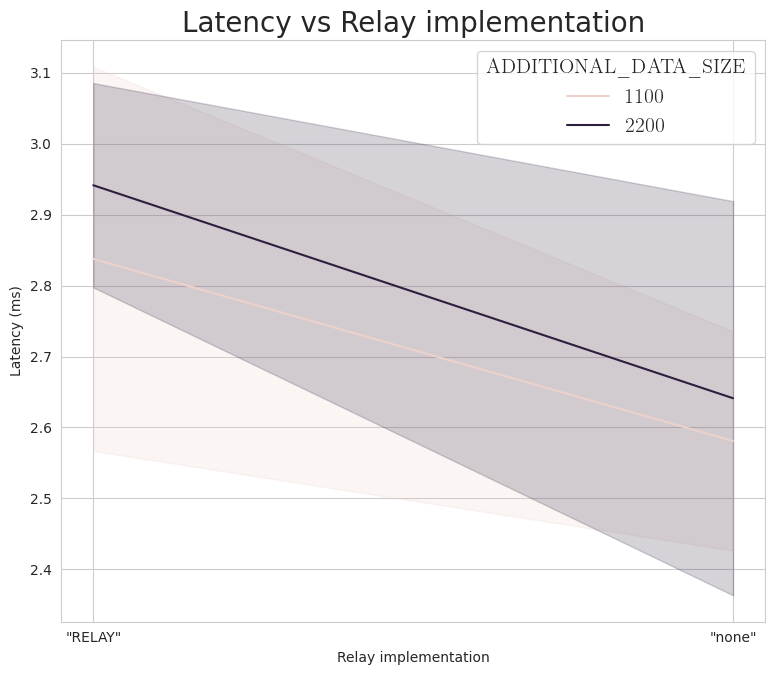

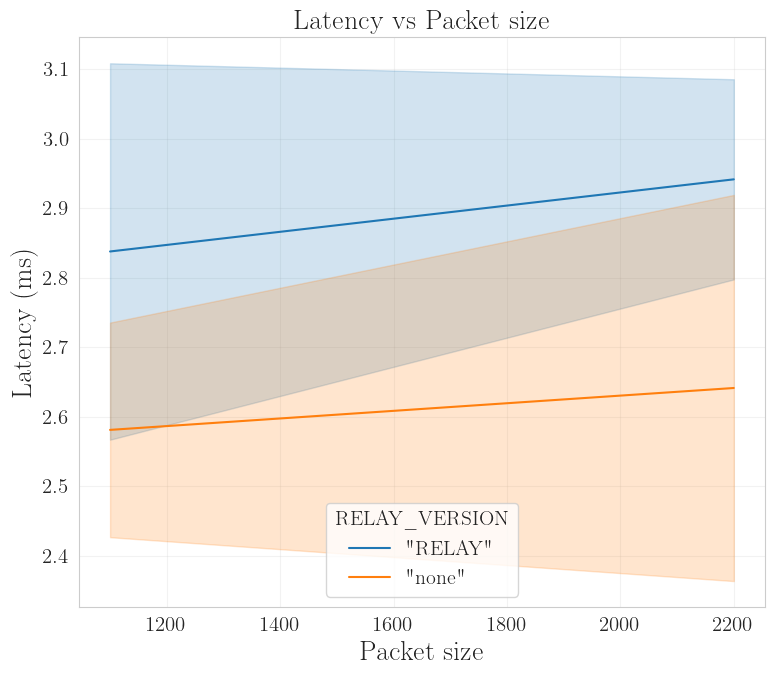

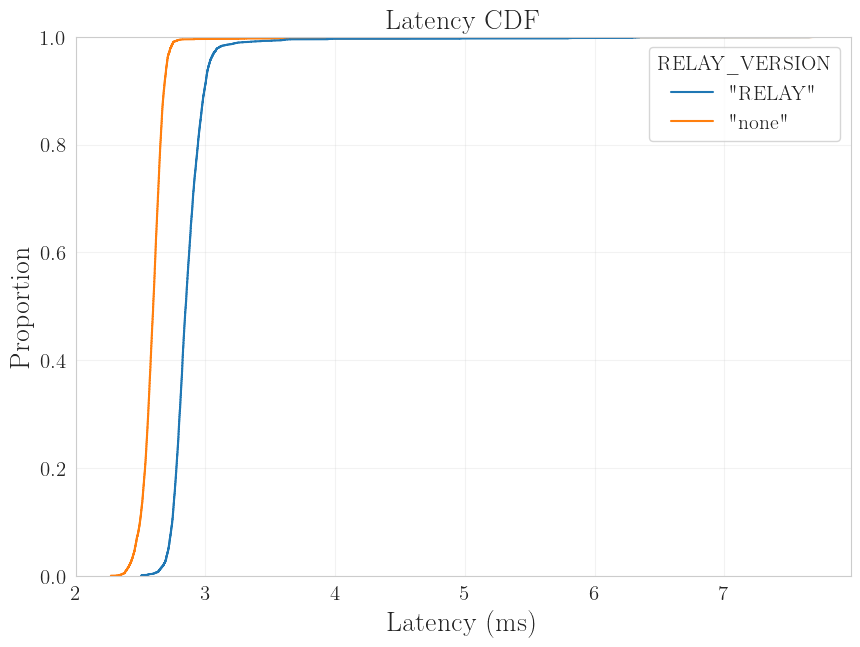

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv(f"./npf-out/{test_name}.csv")
# df = pd.read_csv(f"./npf-out/segmentation_test_tiny_relay_topo_22-04-16-38PM.tar.gz")

# from microseconds to milliseconds
df["y_LATENCY"] = df["y_LATENCY"].div(1000)


sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(8, 7))

sns.lineplot(
    data=df,
    x="RELAY_VERSION",
    y="y_LATENCY",
    hue="ADDITIONAL_DATA_SIZE",
    markers=True,
    errorbar="sd",
    ax=ax,
)
ax.set_xlabel("Relay implementation")
ax.set_ylabel("Latency (ms)")
ax.set_title("Latency vs Relay implementation")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 7))
sns.lineplot(
    data=df,
    x="ADDITIONAL_DATA_SIZE",
    hue="RELAY_VERSION",
    y="y_LATENCY",
    markers=True,
    errorbar="sd",
    ax=ax,
)
ax.set_xlabel("Packet size")
ax.set_ylabel("Latency (ms)")
ax.set_title("Latency vs Packet size")
plt.tight_layout()
plt.show()


# plt.figure()
fig, ax = plt.subplots(figsize=(10, 7))
sns.ecdfplot(data=df, x="y_LATENCY", ax=ax, hue="RELAY_VERSION")
ax.set_xlabel("Latency (ms)")
ax.set_title("Latency CDF")
# plt.tight_layout()
# plt.savefig("latency_cdf.png", dpi=150)
plt.show()

### Compress csv results to be able to push to github
And then delete the csv file

In [7]:
subprocess.run(["cd", "./npf-out/", "tar", "czf", f"./{test_name}.tar.gz", f"./{test_name}.csv"], check=True)
subprocess.run(["rm", f"./npf-out/{test_name}.csv"], check=True)

CompletedProcess(args=['tar', 'czf', './npf-out/latency_test_tiny_relay_topo_22-04-15-57PM.tar.gz', './npf-out/latency_test_tiny_relay_topo_22-04-15-57PM.csv'], returncode=0)

### Stopping the current booking

In [ ]:
provider.destroy()